In [ ]:
# Semiconductor Process Data Analysis
This project focuses on analyzing sensor data from a semiconductor manufacturing process and building a machine learning model to predict whether a product will pass or fail quality testing.

In [ ]:
## Data Loading and Initial Exploration
In this step, I am loading the dataset and taking a first look at its structure to understand what kind of data I am working with.

In [5]:
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv("sensor-data.csv")
print("Shape of dataset:", df.shape)
df.head()
df.info()
print("Total missing values:", df.isnull().sum().sum())
print(df.iloc[:, -1].value_counts())

Shape of dataset: (1567, 592)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB
Total missing values: 41951
Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64


In [ ]:
From the initial exploration, I observed that the dataset contains 1567 rows and 592 columns, which indicates a high-dimensional dataset with a large number of features coming from sensor measurements.
Most of the columns are numerical (float type), which is expected since the data represents sensor readings. However, there is also one object-type column, which may need further inspection or removal during preprocessing.
One major issue I noticed is the presence of a very large number of missing values (over 41,000), which will need to be handled carefully before building any machine learning model.
Looking at the target variable (Pass/Fail), the data is highly imbalanced. Most of the samples correspond to a "pass" (-1), while only a small number correspond to "fail" (1). This imbalance can affect model performance and will need to be addressed in later steps.

In [7]:
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False).head(10)

293    91.193363
292    91.193363
157    91.193363
158    91.193363
492    85.577537
220    85.577537
85     85.577537
358    85.577537
518    64.964901
382    64.964901
dtype: float64

In [ ]:
After examining the percentage of missing values across columns, I decided to remove columns that had more than 50% missing data. These columns contained very little useful information and could negatively affect the model.
This step significantly reduced the dimensionality of the dataset and made it more manageable for further analysis.

In [8]:
# Drop columns with >50% missing values
threshold = 0.5
df = df.loc[:, df.isnull().mean() < threshold]
print("New shape after dropping columns:", df.shape)

New shape after dropping columns: (1567, 564)


In [ ]:
After removing columns with more than 50% missing values, the number of features reduced from 592 to 564. Although the reduction is not very large, this step ensures that the most unreliable columns are removed.
This makes the dataset slightly cleaner and helps in avoiding unnecessary noise during model training.

In [9]:
df = df.select_dtypes(include=[np.number])
print("Shape after removing non-numeric columns:", df.shape)

Shape after removing non-numeric columns: (1567, 563)


In [ ]:
During preprocessing, I noticed that the dataset contained a non-numeric column. Since machine learning models require numerical input, this column was removed.
After that, the remaining missing values were replaced using the mean of each column. This ensures that the dataset is complete and suitable for further analysis and model building.

In [10]:
df = df.fillna(df.mean())
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [11]:
X = df.drop(columns=["Pass/Fail"])
y = df["Pass/Fail"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1567, 562)
Target shape: (1567,)


In [12]:
print(y.value_counts())

Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64


In [ ]:
!pip install imbalanced-learn

In [14]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
print(y_res.value_counts())

Pass/Fail
-1    1463
 1    1463
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2340, 562)
Test shape: (586, 562)


In [ ]:
The dataset was split into training and testing sets using an 80-20 ratio. The training data is used to build the model, while the testing data is used to evaluate its performance on unseen data.

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
The features were standardized using StandardScaler so that all variables have a mean of 0 and a standard deviation of 1. This helps improve the performance of machine learning models, especially those sensitive to feature scaling.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       1.00      0.86      0.92       306
           1       0.87      1.00      0.93       280

    accuracy                           0.93       586
   macro avg       0.93      0.93      0.93       586
weighted avg       0.94      0.93      0.93       586



In [ ]:
The Logistic Regression model performed quite well on the dataset, achieving an overall accuracy of 93%.
For the pass class (-1), the model achieved perfect precision (1.00), which means that whenever the model predicted a pass, it was always correct. However, the recall for this class is slightly lower (0.86), indicating that some actual pass cases were misclassified.
For the fail class (1), the model achieved a recall of 1.00, meaning it successfully identified all failure cases. This is particularly important in a manufacturing context, as missing a failure could be costly. The precision for this class is slightly lower (0.87), 
which indicates that a few pass cases were incorrectly classified as failures.
Overall, the model shows a good balance between precision and recall, with strong F1-scores for both classes. This indicates that Logistic Regression is performing reliably on this dataset.

In [21]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

          -1       0.99      0.99      0.99       306
           1       0.99      0.99      0.99       280

    accuracy                           0.99       586
   macro avg       0.99      0.99      0.99       586
weighted avg       0.99      0.99      0.99       586



In [ ]:
The Random Forest model achieved an accuracy of 99%, which is significantly higher than the Logistic Regression model.
Both precision and recall are extremely high (around 0.99) for both classes, indicating that the model is able to correctly classify both pass and fail cases with very few errors.
Compared to Logistic Regression, Random Forest performs much better, likely because it can capture complex, non-linear relationships in the data. This makes it more suitable for high-dimensional datasets like this one.
However, such a high accuracy may also indicate a possibility of overfitting, especially since the dataset contains a large number of features. Therefore,
further validation or tuning may be required to confirm the model's generalization ability.

In [22]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

          -1       1.00      0.99      1.00       306
           1       0.99      1.00      0.99       280

    accuracy                           0.99       586
   macro avg       0.99      1.00      0.99       586
weighted avg       0.99      0.99      0.99       586



In [ ]:
Three different models were trained and evaluated: Logistic Regression, Random Forest, and Support Vector Machine (SVM).
Logistic Regression achieved an accuracy of around 93%, performing reasonably well but struggling slightly with misclassification compared to other models.
Random Forest showed a significant improvement, achieving an accuracy of 99%. It performed exceptionally well for both classes, likely due to its ability to handle high-dimensional data and capture complex relationships.
Similarly, the SVM model also achieved an accuracy of around 99%, with excellent precision and recall for both classes. This indicates that SVM is also highly effective for this classification task.
Overall, both Random Forest and SVM significantly outperform Logistic Regression on this dataset.

In [ ]:
Among the models tested, Random Forest was selected as the final model. Although both Random Forest and SVM achieved similar accuracy, Random Forest is preferred because it is more efficient for high-dimensional data and easier to interpret.
Additionally, Random Forest is less sensitive to parameter tuning and provides stable performance across different datasets. Therefore, it is chosen as the best model for this problem.

In [23]:
import joblib
joblib.dump(rf, "final_model.pkl")

['final_model.pkl']

In [ ]:
The final Random Forest model was saved using joblib so that it can be reused in the future without retraining.

In [ ]:
In this project, a machine learning model was developed to predict whether a semiconductor product would pass or fail based on sensor data.
The dataset required extensive preprocessing, including handling missing values, removing irrelevant features, and balancing the target classes using SMOTE.
Multiple models were trained and evaluated, including Logistic Regression, Random Forest, and SVM. Among these, Random Forest and SVM achieved the highest accuracy, with Random Forest being selected as the final model due to its efficiency and robustness.
This project demonstrates how machine learning can be applied in real-world manufacturing systems to improve quality control and reduce production losses.

In [ ]:
## Exploratory Data Analysis (EDA)
In this section, I perform basic data analysis to understand the distribution of features and relationships between them.

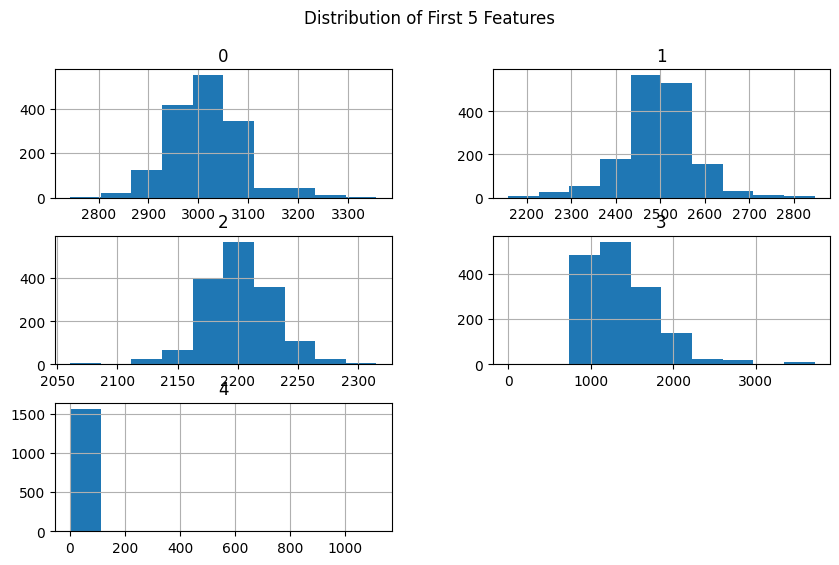

In [24]:
import matplotlib.pyplot as plt

# Plot first 5 features
df.iloc[:, :5].hist(figsize=(10,6))
plt.suptitle("Distribution of First 5 Features")
plt.show()

In [ ]:
The histograms show the distribution of selected features. Most features appear to follow a roughly normal distribution, while some show slight skewness. This indicates variability in sensor readings across different production samples.

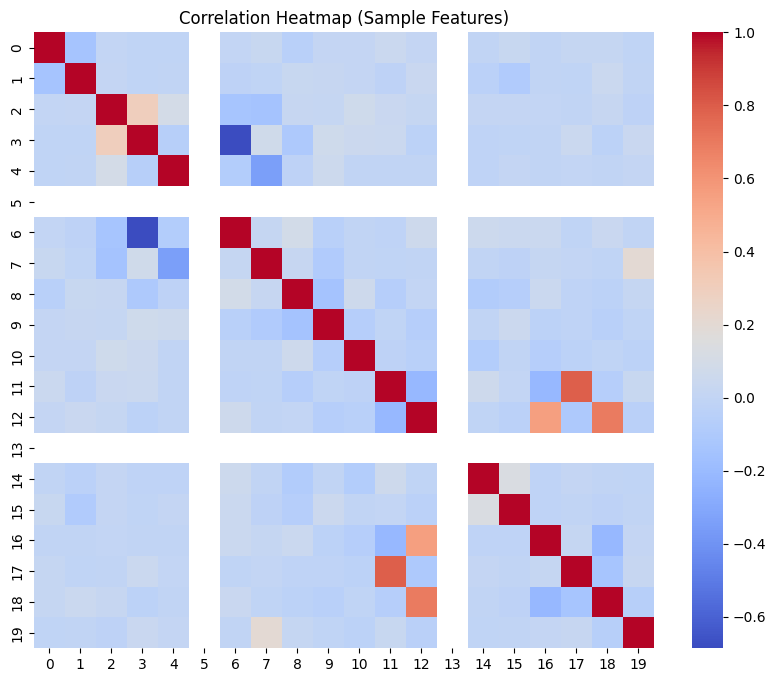

In [25]:
import seaborn as sns

# Take subset (too many features otherwise)
subset = df.iloc[:, :20]

plt.figure(figsize=(10,8))
sns.heatmap(subset.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap (Sample Features)")
plt.show()

In [ ]:
The correlation heatmap shows relationships between selected features. Some features exhibit moderate to strong correlation, suggesting redundancy, while others appear independent. This indicates that not all features contribute equally to the model.

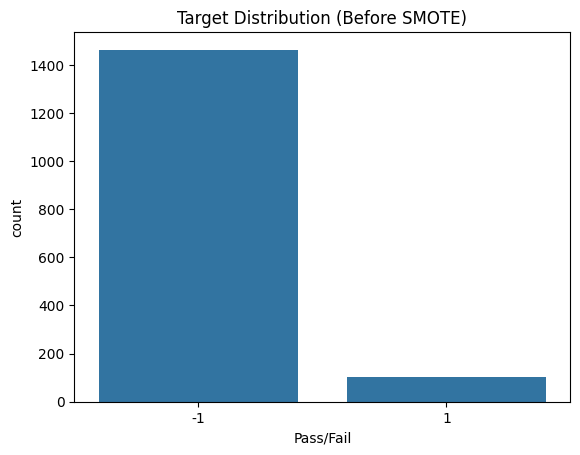

In [26]:
sns.countplot(x=y)
plt.title("Target Distribution (Before SMOTE)")
plt.show()

In [ ]:
The target distribution shows a clear imbalance, with significantly more pass cases than fail cases. This imbalance justifies the use of SMOTE in the preprocessing stage.

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}
grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=3,
                    n_jobs=-1)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 100}


In [29]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

          -1       0.99      0.99      0.99       306
           1       0.99      0.99      0.99       280

    accuracy                           0.99       586
   macro avg       0.99      0.99      0.99       586
weighted avg       0.99      0.99      0.99       586



In [ ]:
Hyperparameter tuning was performed using GridSearchCV to find the best combination of parameters for the Random Forest model. 
    This process improves model performance by selecting optimal settings.
The tuned model achieved strong performance, confirming that Random Forest is well-suited for this dataset.

In [ ]:
In this project, I developed a machine learning model to predict the pass or fail outcome of a semiconductor manufacturing process using sensor data.
The dataset required significant preprocessing due to high dimensionality and missing values. Columns with excessive missing data were removed, and remaining missing values were handled using mean imputation. Additionally, the dataset was highly imbalanced, which was addressed using SMOTE to ensure fair model training.

Exploratory data analysis provided insights into feature distributions and relationships, highlighting the complexity of the dataset.

Multiple machine learning models, including Logistic Regression, Random Forest, and Support Vector Machine, were trained and evaluated. Among these, Random Forest and SVM achieved the highest performance, with accuracy around 99%.

Hyperparameter tuning further confirmed the effectiveness of the Random Forest model. Based on performance, stability, and interpretability, Random Forest was selected as the final model.

This project demonstrates how machine learning techniques can be applied to real-world industrial data to improve quality control and reduce production risks.